In [3]:
import sys
sys.path.insert(0, r"C:\tf")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import pathlib

In [2]:
!python --version

Python 3.11.9


In [4]:
print(tf.__version__)

2.21.0


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 6.31k/6.31k [00:00<00:00, 1.19MB/s]

Extracting files...
Path to dataset files: C:\Users\david\.cache\kagglehub\datasets\uciml\autompg-dataset\versions\3


In [6]:
# Importar el dataset en un DataFrame desde la ruta de KaggleHub
dataset_file = pathlib.Path(path) / "auto-mpg.csv"

if not dataset_file.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {dataset_file}")

df = pd.read_csv(dataset_file)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [7]:
#validar celdas nulas de df
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [11]:
#Eliminar la columna car name
df = df.drop(columns=['car name'], errors='ignore')

#Separar las características del objetivo mpg
X = df.drop(columns=['mpg'])
y = df['mpg']

In [12]:
#Dividir 80% de train en X, y colocar la característica mpg
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

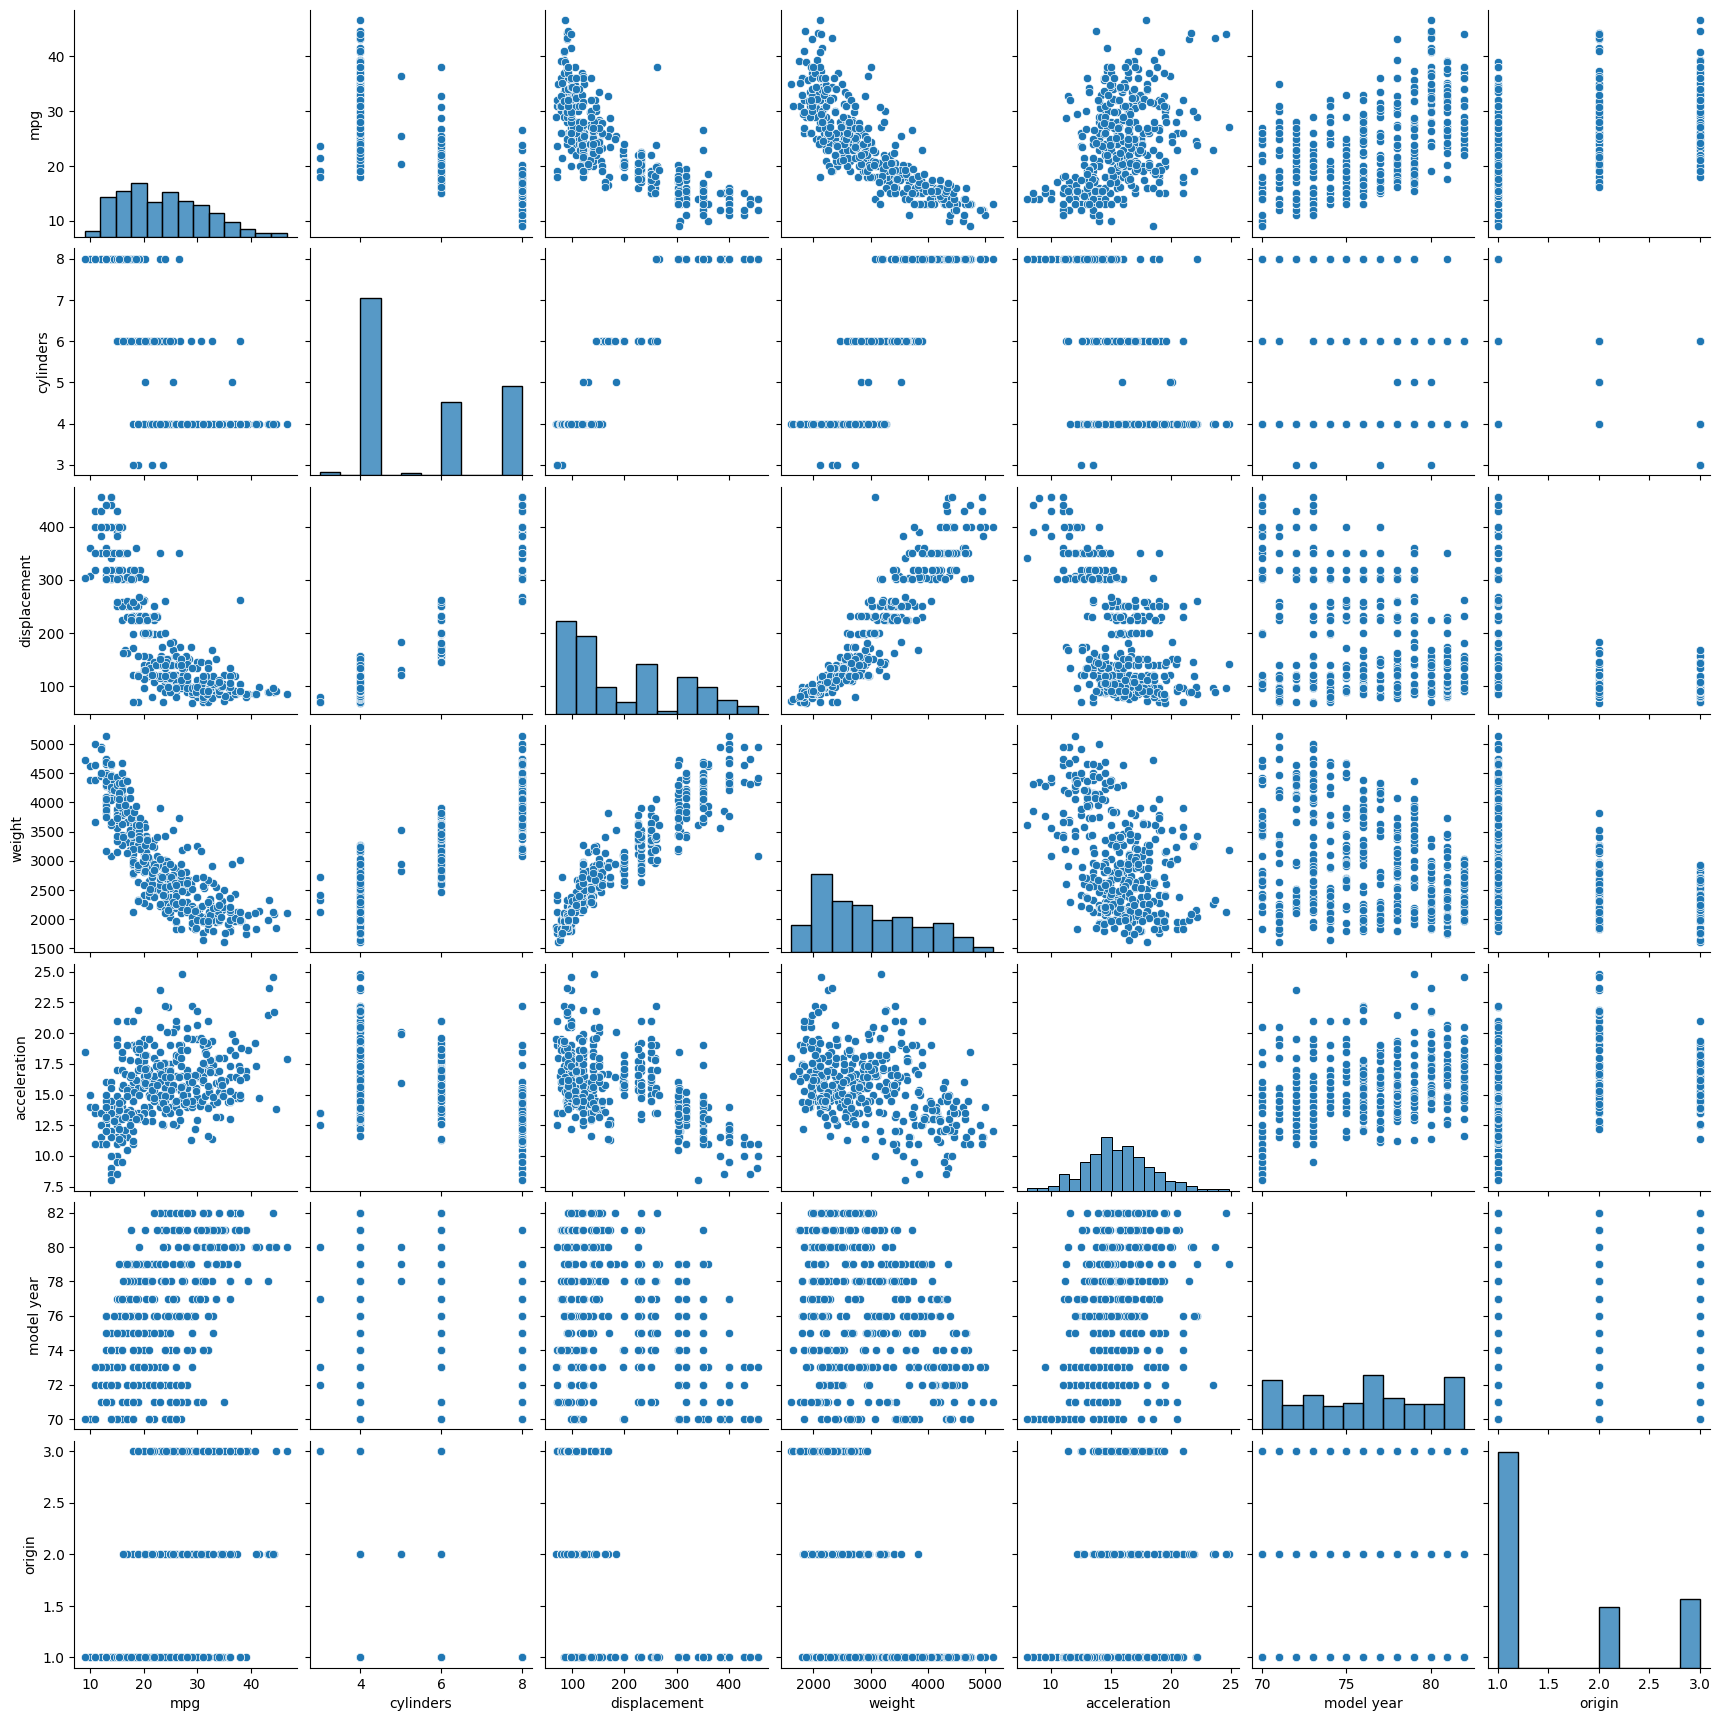

In [13]:
# Analizar las relaciones entre las variables del DataFrame con Seaborn
sns.pairplot(df, diag_kind="hist")
plt.show()

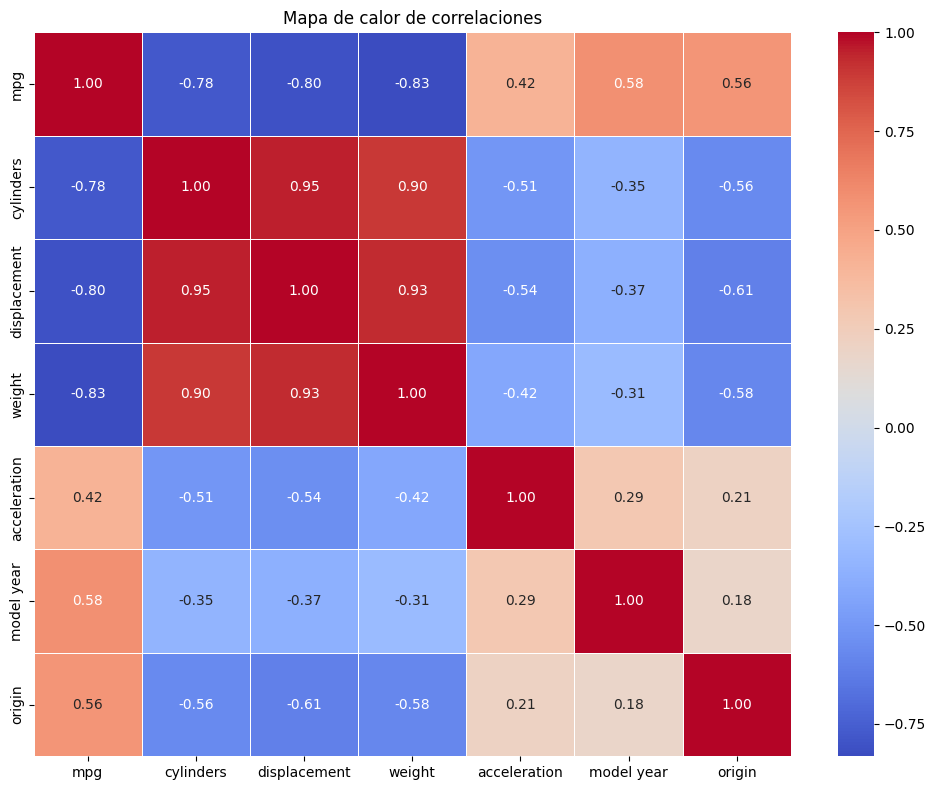

In [14]:
#Mapa de calor de correlación
correlaciones = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Mapa de calor de correlaciones")
plt.tight_layout()
plt.show()

In [15]:
# convertir horsepower en float,  reemplazando '?' por la media
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [16]:
#imputar en horsepower en el nan la media de horsepower
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

In [17]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

In [18]:
# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Normalizar

In [19]:
# normalizar X-train usando standarscaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


In [20]:
X_train_scaled

array([[ 1.52718818,  1.0901965 ,  1.26183446, ..., -1.31933367,
        -1.6966673 , -0.72949361],
       [-0.85051483, -0.92299623, -0.41351298, ..., -0.41318225,
        -1.6966673 ,  1.73836775],
       [-0.85051483, -0.98134964, -0.95394763, ...,  0.92792185,
         1.63897537,  1.73836775],
       ...,
       [-0.85051483, -0.56315019, -0.22436085, ..., -0.30444408,
         0.52709448,  1.73836775],
       [-0.85051483, -1.00080078, -1.11607803, ...,  0.60170734,
         1.36100515,  1.73836775],
       [-0.85051483, -0.92299623, -1.54842576, ...,  1.94281144,
        -0.86275663,  0.50443707]], shape=(318, 7))

In [21]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras import layers

# Crear el modelo secuencial
model = Sequential()

# Capa de entrada
model.add(Input(shape=(X_train_scaled.shape[1],)))

# Capas densas
model.add(layers.Dense(32, activation="relu"))
model.add(layers.Dense(16, activation="relu"))
model.add(layers.Dense(8, activation="relu"))
model.add(layers.Dense(1, activation="linear"))

In [22]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005), 
              loss='mse', 
              metrics=['mae'])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history=model.fit(X_train_scaled, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 581.7587 - mae: 22.7195 - val_loss: 507.6167 - val_mae: 21.1210
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 432.8248 - mae: 19.0061 - val_loss: 299.8147 - val_mae: 15.5537
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 193.0601 - mae: 12.0958 - val_loss: 82.8003 - val_mae: 7.6348
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 63.2148 - mae: 6.5706 - val_loss: 40.3345 - val_mae: 5.1885
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 39.3143 - mae: 5.1192 - val_loss: 24.9743 - val_mae: 3.9729
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 27.7274 - mae: 4.3066 - val_loss: 18.1765 - val_mae: 3.3509
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 21.0255 - mae: 3.5909 - val_loss: 13.4372 - val_mae: 2.8835
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 17.0703 - mae: 3.2112 - val_loss: 12.2505 - val_mae: 2.6984
Epoch 9/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/s

Text(0, 0.5, 'Pérdida')

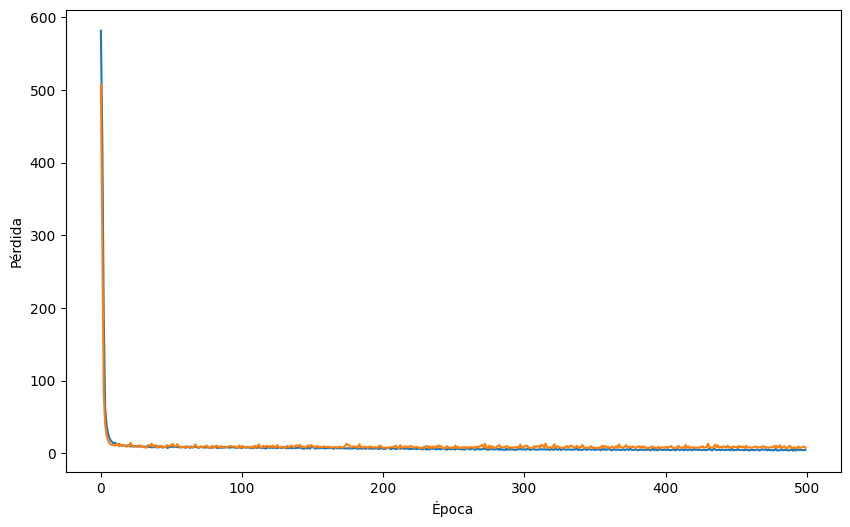

In [25]:
#Graficame el history de los datos de entrenamiento y datos de valuación, las metricas y la función de perdida
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')


In [26]:
keras.models.save_model(model, "model_mpg.keras")

In [27]:
#predecir con los datos de X_test
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [28]:
#calcular el error medio absoluto (MAE) y el error cuadrático medio (MSE) de las predicciones
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)